In [1]:
import pandas as pd, sqlite3
from google.colab import files

uploaded = files.upload()  # select nifty50_prices_long.csv

df = pd.read_csv('nifty50_prices_long.csv')
conn = sqlite3.connect('momentum.db')
df.to_sql('price_history', conn, if_exists='replace', index=False)
conn.execute("CREATE INDEX idx_ticker_date ON price_history(ticker, date)")
conn.commit()
pd.read_sql("SELECT ticker, MIN(date), MAX(date), COUNT(*) FROM price_history GROUP BY ticker LIMIT 5", conn)

Saving nifty50_prices_long.csv to nifty50_prices_long.csv


,ticker,MIN(date),MAX(date),COUNT(*)
0,ADANIENT,2023-01-02,2026-06-17,849
1,ADANIPORTS,2023-01-02,2026-06-17,849
2,APOLLOHOSP,2023-01-02,2026-06-17,848
3,ASIANPAINT,2023-01-02,2026-06-17,849
4,AXISBANK,2023-01-02,2026-06-17,849


In [2]:
q2 = """
WITH month_end AS (
  SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
         ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
  FROM price_history
)
SELECT ticker, month, date, close FROM month_end WHERE rn = 1
"""
monthly_prices = pd.read_sql(q2, conn)
monthly_prices.head(10)

,ticker,month,date,close
0,ADANIENT,2023-01,2023-01-31,2883.15
1,ADANIENT,2023-02,2023-02-28,1322.23
2,ADANIENT,2023-03,2023-03-31,1697.04
3,ADANIENT,2023-04,2023-04-28,1866.21
4,ADANIENT,2023-05,2023-05-31,2417.27
5,ADANIENT,2023-06,2023-06-30,2315.18
6,ADANIENT,2023-07,2023-07-31,2416.15
7,ADANIENT,2023-08,2023-08-31,2345.43
8,ADANIENT,2023-09,2023-09-29,2340.24
9,ADANIENT,2023-10,2023-10-31,2224.63


In [3]:
q3 = """
WITH month_end AS (
  SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
         ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
  FROM price_history
),
monthly_prices AS (SELECT ticker, month, date, close FROM month_end WHERE rn = 1)
SELECT ticker, month, close,
       close / LAG(close,1) OVER (PARTITION BY ticker ORDER BY month) - 1 AS monthly_return,
       close / LAG(close,6) OVER (PARTITION BY ticker ORDER BY month) - 1 AS momentum_6m
FROM monthly_prices
"""
monthly_returns = pd.read_sql(q3, conn)
monthly_returns[monthly_returns.ticker=='RELIANCE'].head(10)

,ticker,month,close,monthly_return,momentum_6m
1559,RELIANCE,2023-01,1176.93,NaN,NaN
1560,RELIANCE,2023-02,1161.28,-0.013297,NaN
1561,RELIANCE,2023-03,1165.53,0.003660,NaN
1562,RELIANCE,2023-04,1210.25,0.038369,NaN
1563,RELIANCE,2023-05,1234.95,0.020409,NaN
1564,RELIANCE,2023-06,1275.13,0.032536,NaN
1565,RELIANCE,2023-07,1274.63,-0.000392,0.083013
1566,RELIANCE,2023-08,1203.50,-0.055804,0.036356
1567,RELIANCE,2023-09,1172.50,-0.025758,0.005980
1568,RELIANCE,2023-10,1143.95,-0.024350,-0.054782


In [4]:
q4 = """
WITH month_end AS (
  SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
         ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
  FROM price_history
),
monthly_prices AS (SELECT ticker, month, date, close FROM month_end WHERE rn = 1),
monthly_returns AS (
  SELECT ticker, month, close,
         close / LAG(close,1) OVER (PARTITION BY ticker ORDER BY month) - 1 AS monthly_return,
         close / LAG(close,6) OVER (PARTITION BY ticker ORDER BY month) - 1 AS momentum_6m
  FROM monthly_prices
)
SELECT *, RANK() OVER (PARTITION BY month ORDER BY momentum_6m DESC) AS momentum_rank
FROM monthly_returns
WHERE ticker != 'NIFTY50_INDEX' AND momentum_6m IS NOT NULL
"""
ranked = pd.read_sql(q4, conn)
ranked[ranked.month=='2023-07'].sort_values('momentum_rank').head(10)

,ticker,month,close,monthly_return,momentum_6m,momentum_rank
0,SHRIRAMFIN,2023-07,378.63,0.091027,0.471436,1
1,TMPV,2023-07,390.04,0.081852,0.425116,2
2,ITC,2023-07,465.70,0.031222,0.321697,3
3,INDUSINDBK,2023-07,1417.75,0.031353,0.309156,4
4,DRREDDY,2023-07,1128.09,0.093195,0.304407,5
5,BAJAJ-AUTO,2023-07,4931.40,0.051124,0.291534,6
6,NTPC,2023-07,218.35,0.154375,0.275781,7
7,ADANIPORTS,2023-07,777.85,0.052215,0.269648,8
8,TITAN,2023-07,3004.05,-0.014306,0.263719,9
9,LT,2023-07,2681.35,0.083133,0.262168,10


In [5]:
monthly_returns = pd.read_sql("""
WITH month_end AS (
  SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
         ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
  FROM price_history
)
SELECT ticker, month, close,
       close / LAG(close,1) OVER (PARTITION BY ticker ORDER BY date) - 1 AS monthly_return,
       close / LAG(close,6) OVER (PARTITION BY ticker ORDER BY date) - 1 AS momentum_6m
FROM month_end WHERE rn = 1
""", conn)
monthly_returns.to_sql('monthly_returns', conn, if_exists='replace', index=False)

2105

In [6]:
q5 = """
WITH ranked AS (
  SELECT *, RANK() OVER (PARTITION BY month ORDER BY momentum_6m DESC) AS momentum_rank
  FROM monthly_returns
  WHERE ticker != 'NIFTY50_INDEX' AND momentum_6m IS NOT NULL
),
top_picks AS (SELECT * FROM ranked WHERE momentum_rank <= 10)
SELECT t.month AS formation_month,
       strftime('%Y-%m', date(t.month || '-01', '+1 month')) AS holding_month,
       ROUND(AVG(mr.monthly_return)*100, 2) AS strategy_pct,
       ROUND(b.benchmark_return*100, 2) AS index_pct,
       CASE WHEN AVG(mr.monthly_return) > b.benchmark_return THEN 'Beat Index' ELSE 'Underperformed' END AS result
FROM top_picks t
JOIN monthly_returns mr ON mr.ticker = t.ticker
     AND mr.month = strftime('%Y-%m', date(t.month || '-01', '+1 month'))
JOIN (SELECT month, monthly_return AS benchmark_return FROM monthly_returns WHERE ticker='NIFTY50_INDEX') b
     ON b.month = strftime('%Y-%m', date(t.month || '-01', '+1 month'))
GROUP BY t.month
ORDER BY holding_month
"""
results = pd.read_sql(q5, conn)
print(f"Beat index: {(results.result=='Beat Index').sum()}/{len(results)}")
results

Beat index: 23/35


,formation_month,holding_month,strategy_pct,index_pct,result
0,2023-07,2023-08,-1.34,-2.53,Beat Index
1,2023-08,2023-09,2.59,2.00,Beat Index
2,2023-09,2023-10,-2.73,-2.84,Beat Index
3,2023-10,2023-11,8.29,5.52,Beat Index
4,2023-11,2023-12,9.73,7.94,Beat Index
5,2023-12,2024-01,7.85,-0.03,Beat Index
6,2024-01,2024-02,5.56,1.18,Beat Index
7,2024-02,2024-03,1.90,1.57,Beat Index
8,2024-03,2024-04,1.46,1.24,Beat Index
9,2024-04,2024-05,2.99,-0.33,Beat Index


In [7]:
q6 = """
WITH ranked AS (
  SELECT ticker, RANK() OVER (PARTITION BY month ORDER BY momentum_6m DESC) AS momentum_rank
  FROM monthly_returns
  WHERE ticker != 'NIFTY50_INDEX' AND momentum_6m IS NOT NULL
)
SELECT DISTINCT p.ticker
FROM price_history p
LEFT JOIN (SELECT DISTINCT ticker FROM ranked WHERE momentum_rank <= 10) picked
     ON p.ticker = picked.ticker
WHERE p.ticker != 'NIFTY50_INDEX' AND picked.ticker IS NULL
"""
pd.read_sql(q6, conn)

,ticker
0,LTM
1,TCS


In [ ]:
hit_rate = (results['strategy_pct'] > results['index_pct']).mean()*100
strat_ret = results['strategy_pct']/100
idx_ret = results['index_pct']/100

cum_strat = ((1+strat_ret).prod()-1)*100
cum_idx = ((1+idx_ret).prod()-1)*100

print(f"Months tested: {len(results)}")
print(f"Hit rate: {hit_rate:.1f}%")
print(f"Avg monthly return — strategy: {strat_ret.mean()*100:.2f}%  index: {idx_ret.mean()*100:.2f}%")
print(f"Cumulative return — strategy: {cum_strat:.2f}%  index: {cum_idx:.2f}%")
print(f"Best month — strategy: {strat_ret.max()*100:.2f}%  Worst: {strat_ret.min()*100:.2f}%")

Months tested: 35
Hit rate: 65.7%
Avg monthly return — strategy: 1.08%  index: 0.65%
Cumulative return — strategy: 39.57%  index: 21.90%
Best month — strategy: 9.73%  Worst: -14.35%


In [8]:
q_features = """
WITH month_end AS (
  SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
         ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
  FROM price_history
),
monthly_prices AS (SELECT ticker, month, close FROM month_end WHERE rn = 1),
monthly_returns AS (
  SELECT ticker, month, close,
         close / LAG(close,1)  OVER (PARTITION BY ticker ORDER BY month) - 1 AS ret_1m,
         close / LAG(close,3)  OVER (PARTITION BY ticker ORDER BY month) - 1 AS ret_3m,
         close / LAG(close,6)  OVER (PARTITION BY ticker ORDER BY month) - 1 AS ret_6m,
         close / LAG(close,12) OVER (PARTITION BY ticker ORDER BY month) - 1 AS ret_12m
  FROM monthly_prices
)
SELECT ticker, month, ret_1m, ret_3m, ret_6m, ret_12m
FROM monthly_returns
WHERE ticker != 'NIFTY50_INDEX'
"""
features = pd.read_sql(q_features, conn)
features.head(10)

,ticker,month,ret_1m,ret_3m,ret_6m,ret_12m
0,ADANIENT,2023-01,NaN,NaN,NaN,NaN
1,ADANIENT,2023-02,-0.541394,NaN,NaN,NaN
2,ADANIENT,2023-03,0.283468,NaN,NaN,NaN
3,ADANIENT,2023-04,0.099685,-0.352718,NaN,NaN
4,ADANIENT,2023-05,0.295283,0.828177,NaN,NaN
5,ADANIENT,2023-06,-0.042234,0.364246,NaN,NaN
6,ADANIENT,2023-07,0.043612,0.294683,-0.161976,NaN
7,ADANIENT,2023-08,-0.029270,-0.029719,0.773844,NaN
8,ADANIENT,2023-09,-0.002213,0.010824,0.379013,NaN
9,ADANIENT,2023-10,-0.049401,-0.079267,0.192058,NaN


In [11]:
import pandas as pd

# Volatility: rolling 6-month std of monthly returns
features = features.sort_values(['ticker', 'month'])
features['volatility_6m'] = (
    features.groupby('ticker')['ret_1m']
    .transform(lambda x: x.rolling(6).std())
)

# Pull index returns and all stock next-month returns
index_rets = pd.read_sql("SELECT month, monthly_return AS index_ret FROM monthly_returns WHERE ticker = 'NIFTY50_INDEX'", conn)
stock_next = pd.read_sql("SELECT ticker, month, monthly_return AS next_ret FROM monthly_returns WHERE ticker != 'NIFTY50_INDEX'", conn)

# Shift features month forward by 1 month using string manipulation
features['next_month'] = pd.to_datetime(features['month'].astype(str)).apply(
    lambda x: (x + pd.DateOffset(months=1)).strftime('%Y-%m')
)

# Merge
features = features.merge(stock_next.rename(columns={'month':'next_month'}), on=['ticker','next_month'], how='left')
features = features.merge(index_rets.rename(columns={'month':'next_month'}), on='next_month', how='left')

# Target
features['target'] = (features['next_ret'] > features['index_ret']).astype(int)

# Drop NaNs
ml_df = features.dropna(subset=['ret_1m','ret_3m','ret_6m','ret_12m','volatility_6m','target'])
print(ml_df.shape)
ml_df[['ticker','month','ret_6m','volatility_6m','target']].head(10)

(1470, 11)


,ticker,month,ret_6m,volatility_6m,target
12,ADANIENT,2024-01,0.260733,0.096765,1
13,ADANIENT,2024-02,0.358024,0.090192,0
14,ADANIENT,2024-03,0.324454,0.093834,0
15,ADANIENT,2024-04,0.331228,0.092805,1
16,ADANIENT,2024-05,0.446374,0.095216,0
17,ADANIENT,2024-06,0.115202,0.078870,0
18,ADANIENT,2024-07,0.008723,0.067932,0
19,ADANIENT,2024-08,-0.080982,0.066944,1
20,ADANIENT,2024-09,-0.019158,0.069361,1
21,ADANIENT,2024-10,-0.035178,0.071565,0


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

feature_cols = ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'volatility_6m']

# Train on 2024, test on 2025 onwards
train = ml_df[ml_df['month'] < '2025-01']
test  = ml_df[ml_df['month'] >= '2025-01']

X_train, y_train = train[feature_cols], train['target']
X_test,  y_test  = test[feature_cols],  test['target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(classification_report(y_test, y_pred))

Accuracy: 50.1%
              precision    recall  f1-score   support

           0       0.51      0.37      0.43       445
           1       0.50      0.64      0.56       437

    accuracy                           0.50       882
   macro avg       0.50      0.50      0.49       882
weighted avg       0.50      0.50      0.49       882



In [14]:
# Add momentum rank from the features dataframe (already has ret_6m)
ml_df['momentum_rank'] = ml_df.groupby('month')['ret_6m'].rank(ascending=False)

feature_cols = ['ret_1m', 'ret_3m', 'ret_6m', 'ret_12m', 'volatility_6m', 'momentum_rank']

train = ml_df[ml_df['month'] < '2025-01']
test  = ml_df[ml_df['month'] >= '2025-01']

X_train, y_train = train[feature_cols], train['target']
X_test,  y_test  = test[feature_cols],  test['target']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print(classification_report(y_test, y_pred))

/tmp/ipykernel_1649/2576175936.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_df['momentum_rank'] = ml_df.groupby('month')['ret_6m'].rank(ascending=False)


Accuracy: 49.1%
              precision    recall  f1-score   support

           0       0.49      0.36      0.42       445
           1       0.49      0.62      0.55       437

    accuracy                           0.49       882
   macro avg       0.49      0.49      0.48       882
weighted avg       0.49      0.49      0.48       882



In [16]:
# Get predicted probabilities for each stock each month
test_df = ml_df[ml_df['month'] >= '2025-01'].copy()
test_df['prob_outperform'] = rf.predict_proba(test_df[feature_cols])[:, 1]

# ML top-10 and rules-based top-10
ml_picks    = test_df.sort_values('prob_outperform', ascending=False).groupby('month').head(10)
rules_picks = test_df.sort_values('ret_6m', ascending=False).groupby('month').head(10)

# Average next month return for each
ml_monthly    = ml_picks.groupby('month')['next_ret'].mean().reset_index()
ml_monthly.columns = ['month', 'ml_return']

rules_monthly = rules_picks.groupby('month')['next_ret'].mean().reset_index()
rules_monthly.columns = ['month', 'rules_return']

# Index return for same period
index_test = pd.read_sql("""
    SELECT month, monthly_return AS index_ret FROM monthly_returns
    WHERE ticker = 'NIFTY50_INDEX'
""", conn)

# Merge and compare
comparison = ml_monthly.merge(rules_monthly, on='month').merge(index_test, on='month')
comparison = comparison.dropna()

comparison['ml_beat_index']    = comparison['ml_return'] > comparison['index_ret']
comparison['rules_beat_index'] = comparison['rules_return'] > comparison['index_ret']

print(f"ML beat index:    {comparison['ml_beat_index'].sum()}/{len(comparison)}")
print(f"Rules beat index: {comparison['rules_beat_index'].sum()}/{len(comparison)}")
print()
print(f"ML cumulative return:    {((1+comparison['ml_return']).prod()-1)*100:.2f}%")
print(f"Rules cumulative return: {((1+comparison['rules_return']).prod()-1)*100:.2f}%")
print(f"Index cumulative return: {((1+comparison['index_ret']).prod()-1)*100:.2f}%")
print()
comparison[['month','ml_return','rules_return','index_ret']].round(4)

ML beat index:    7/17
Rules beat index: 7/17

ML cumulative return:    9.40%
Rules cumulative return: 2.33%
Index cumulative return: -0.41%



,month,ml_return,rules_return,index_ret
0,2025-01,-0.0492,-0.0260,-0.0058
1,2025-02,0.0803,0.0720,-0.0589
2,2025-03,0.0283,0.0227,0.0630
3,2025-04,0.0342,-0.0006,0.0346
4,2025-05,0.0415,0.0287,0.0171
5,2025-06,-0.0195,-0.0534,0.0310
6,2025-07,0.0302,-0.0404,-0.0293
7,2025-08,0.0105,0.0421,-0.0138
8,2025-09,0.0317,0.0346,0.0075
9,2025-10,0.0261,0.0239,0.0451


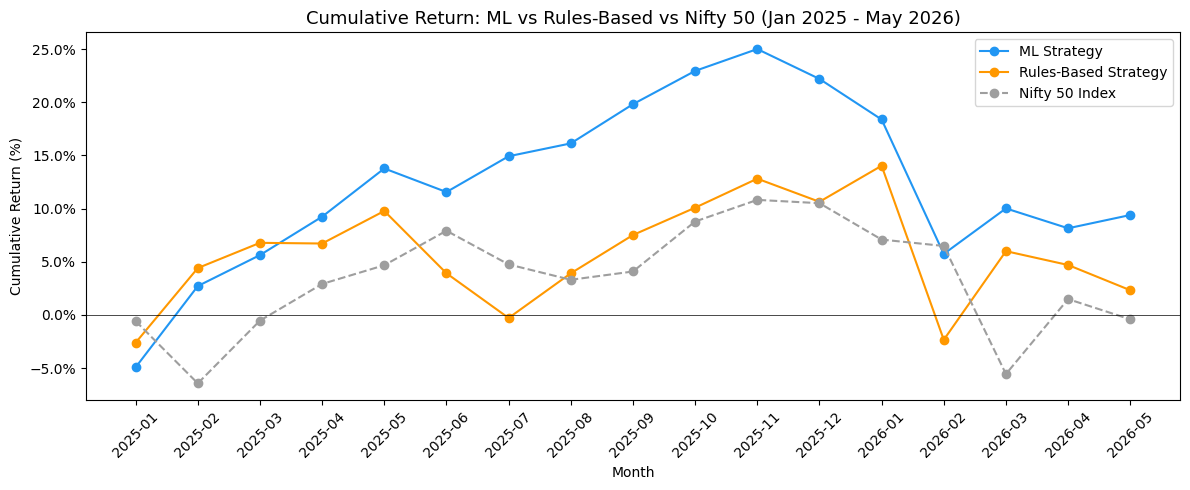

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

comp = comparison.copy()
comp['cum_ml']    = (1 + comp['ml_return']).cumprod() - 1
comp['cum_rules'] = (1 + comp['rules_return']).cumprod() - 1
comp['cum_index'] = (1 + comp['index_ret']).cumprod() - 1

plt.figure(figsize=(12, 5))
plt.plot(comp['month'], comp['cum_ml']    * 100, marker='o', label='ML Strategy',         color='#2196F3')
plt.plot(comp['month'], comp['cum_rules'] * 100, marker='o', label='Rules-Based Strategy', color='#FF9800')
plt.plot(comp['month'], comp['cum_index'] * 100, marker='o', label='Nifty 50 Index',       color='#9E9E9E', linestyle='--')

plt.axhline(0, color='black', linewidth=0.5)
plt.title('Cumulative Return: ML vs Rules-Based vs Nifty 50 (Jan 2025 - May 2026)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Cumulative Return (%)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.tight_layout()
plt.show()

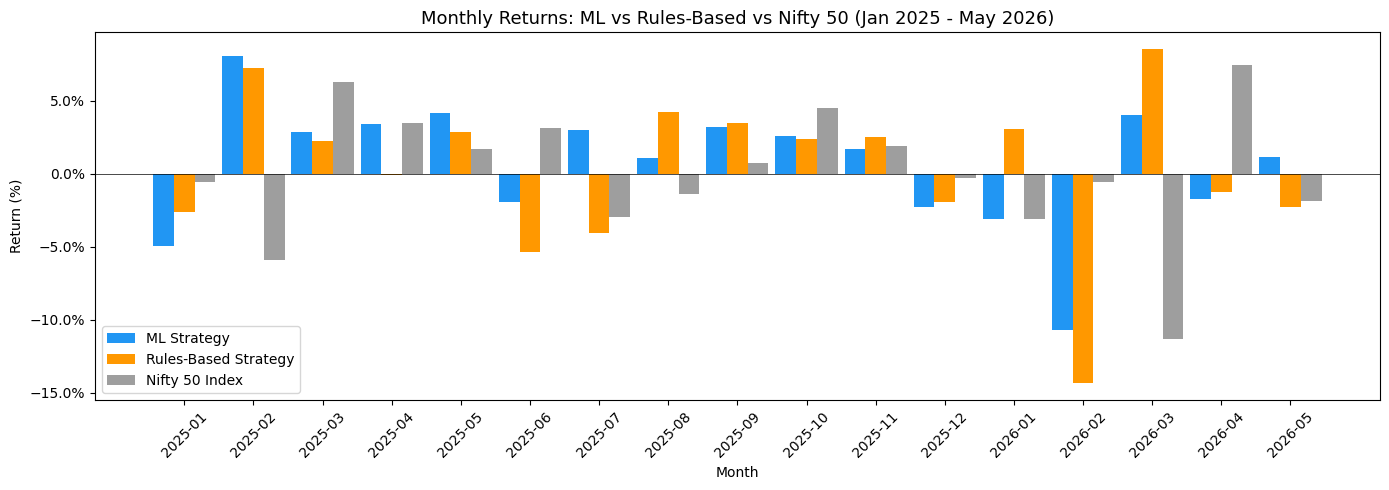

In [18]:
x = range(len(comp))
width = 0.3

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - width for i in x], comp['ml_return']    * 100, width=width, label='ML Strategy',         color='#2196F3')
ax.bar([i          for i in x], comp['rules_return'] * 100, width=width, label='Rules-Based Strategy', color='#FF9800')
ax.bar([i + width for i in x], comp['index_ret']    * 100, width=width, label='Nifty 50 Index',       color='#9E9E9E')

ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Monthly Returns: ML vs Rules-Based vs Nifty 50 (Jan 2025 - May 2026)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Return (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(comp['month'], rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.show()

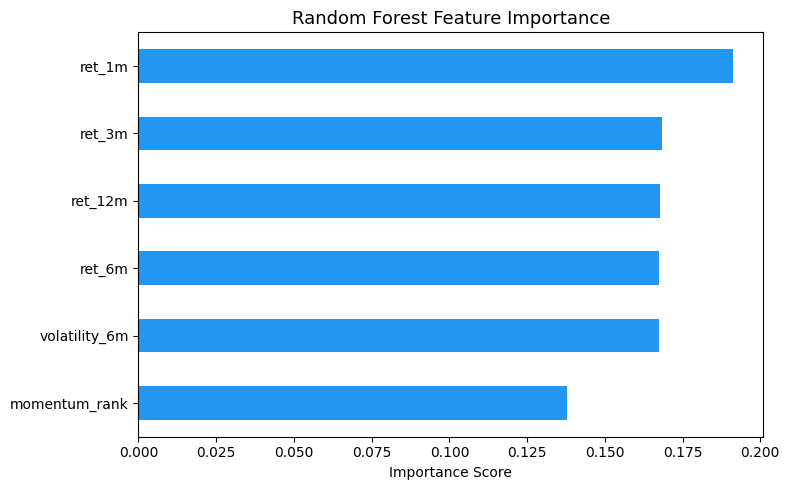

In [19]:
feat_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='barh', color='#2196F3')
plt.title('Random Forest Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

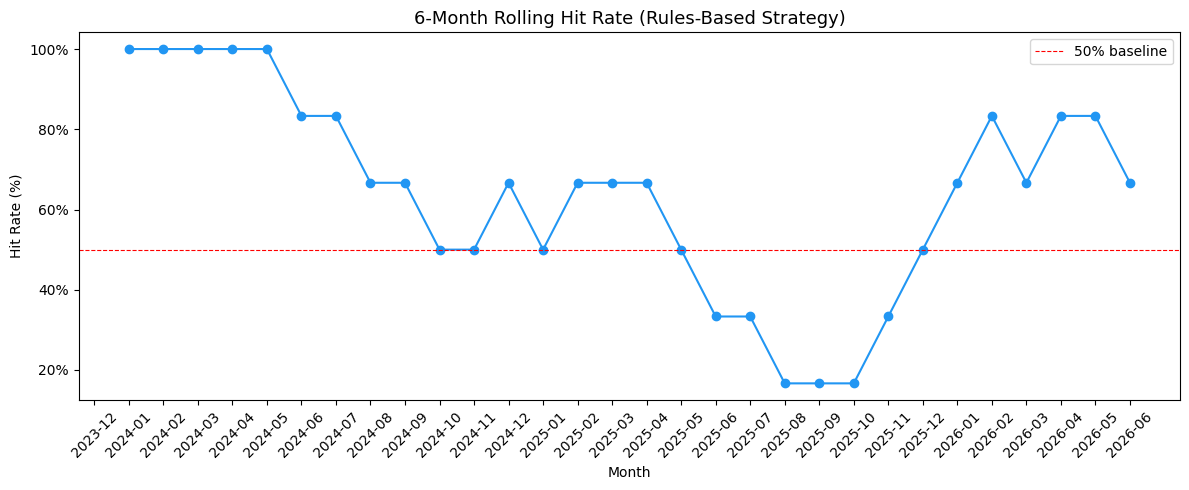

In [20]:
full_results = pd.read_sql("""
    WITH month_end AS (
      SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
             ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
      FROM price_history
    ),
    monthly_prices AS (SELECT ticker, month, close FROM month_end WHERE rn = 1),
    monthly_returns AS (
      SELECT ticker, month, close,
             close / LAG(close,1) OVER (PARTITION BY ticker ORDER BY month) - 1 AS monthly_return,
             close / LAG(close,6) OVER (PARTITION BY ticker ORDER BY month) - 1 AS momentum_6m
      FROM monthly_prices
    ),
    ranked AS (
      SELECT *, RANK() OVER (PARTITION BY month ORDER BY momentum_6m DESC) AS momentum_rank
      FROM monthly_returns WHERE ticker != 'NIFTY50_INDEX' AND momentum_6m IS NOT NULL
    ),
    top_picks AS (SELECT * FROM ranked WHERE momentum_rank <= 10),
    portfolio_returns AS (
      SELECT t.month AS formation_month,
             strftime('%Y-%m', date(t.month || '-01', '+1 month')) AS holding_month,
             AVG(mr.monthly_return) AS portfolio_return
      FROM top_picks t
      JOIN monthly_returns mr ON mr.ticker = t.ticker
           AND mr.month = strftime('%Y-%m', date(t.month || '-01', '+1 month'))
      GROUP BY t.month
    ),
    benchmark AS (SELECT month, monthly_return AS benchmark_return FROM monthly_returns WHERE ticker = 'NIFTY50_INDEX')
    SELECT p.holding_month, p.portfolio_return, b.benchmark_return
    FROM portfolio_returns p JOIN benchmark b ON b.month = p.holding_month
    ORDER BY p.holding_month
""", conn)

full_results['beat'] = (full_results['portfolio_return'] > full_results['benchmark_return']).astype(int)
full_results['rolling_hit_rate'] = full_results['beat'].rolling(6).mean() * 100

plt.figure(figsize=(12, 5))
plt.plot(full_results['holding_month'], full_results['rolling_hit_rate'], marker='o', color='#2196F3')
plt.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% baseline')
plt.title('6-Month Rolling Hit Rate (Rules-Based Strategy)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Hit Rate (%)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.tight_layout()
plt.show()

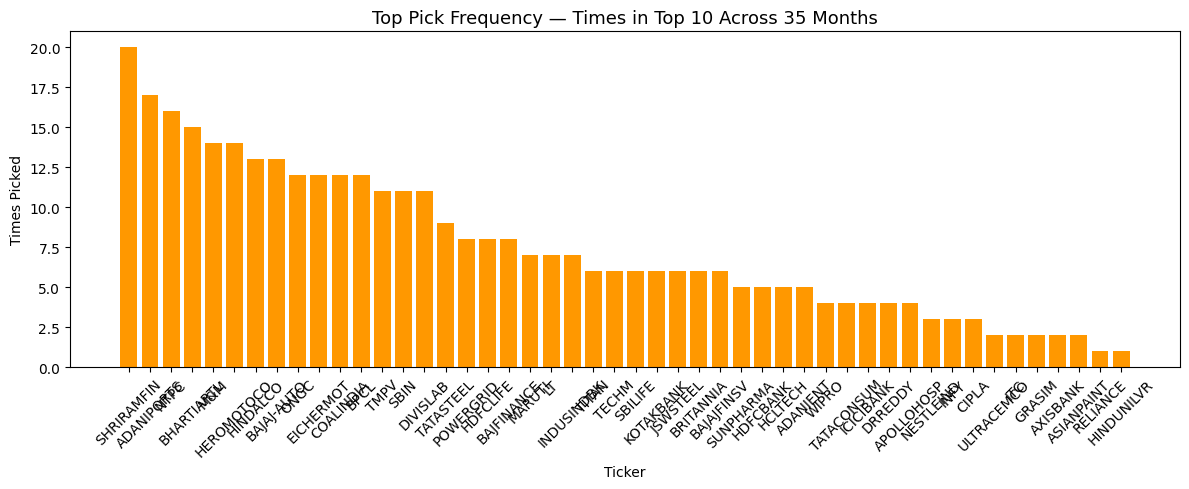

In [21]:
top_picks_all = pd.read_sql("""
    WITH month_end AS (
      SELECT ticker, date, close, strftime('%Y-%m', date) AS month,
             ROW_NUMBER() OVER (PARTITION BY ticker, strftime('%Y-%m', date) ORDER BY date DESC) AS rn
      FROM price_history
    ),
    monthly_prices AS (SELECT ticker, month, close FROM month_end WHERE rn = 1),
    monthly_returns AS (
      SELECT ticker, month,
             close / LAG(close,6) OVER (PARTITION BY ticker ORDER BY month) - 1 AS momentum_6m
      FROM monthly_prices
    ),
    ranked AS (
      SELECT *, RANK() OVER (PARTITION BY month ORDER BY momentum_6m DESC) AS momentum_rank
      FROM monthly_returns WHERE ticker != 'NIFTY50_INDEX' AND momentum_6m IS NOT NULL
    )
    SELECT ticker, COUNT(*) AS times_picked
    FROM ranked WHERE momentum_rank <= 10
    GROUP BY ticker
    ORDER BY times_picked DESC
""", conn)

plt.figure(figsize=(12, 5))
plt.bar(top_picks_all['ticker'], top_picks_all['times_picked'], color='#FF9800')
plt.title('Top Pick Frequency — Times in Top 10 Across 35 Months', fontsize=13)
plt.xlabel('Ticker')
plt.ylabel('Times Picked')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
from google.colab import files

# Full 35-month backtest
full_results[['holding_month','portfolio_return','benchmark_return','beat']].to_csv('backtest_results.csv', index=False)
files.download('backtest_results.csv')

# ML comparison
comparison[['month','ml_return','rules_return','index_ret']].to_csv('ml_comparison.csv', index=False)
files.download('ml_comparison.csv')

# Top picks frequency
top_picks_all.to_csv('top_picks_frequency.csv', index=False)
files.download('top_picks_frequency.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

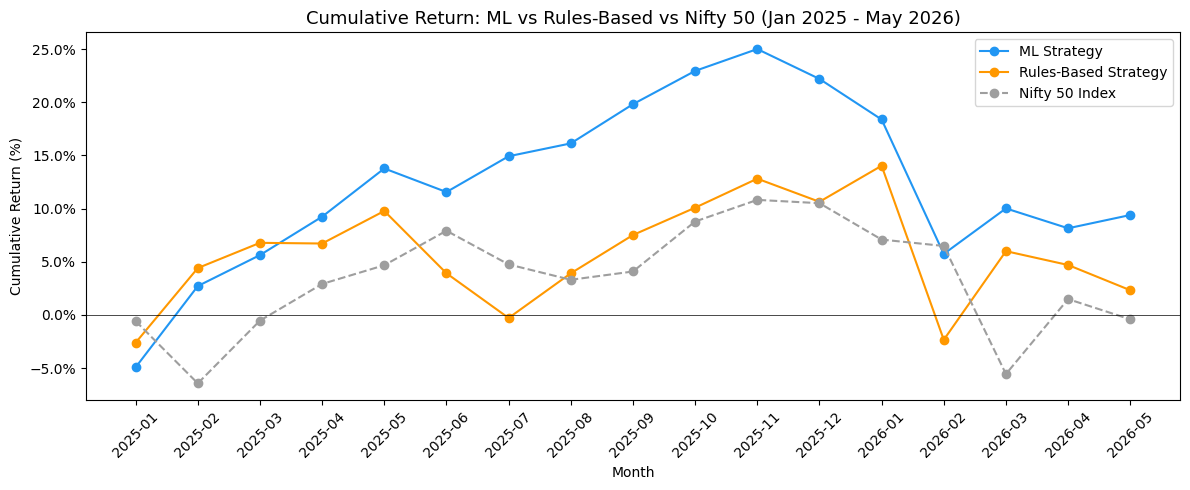

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

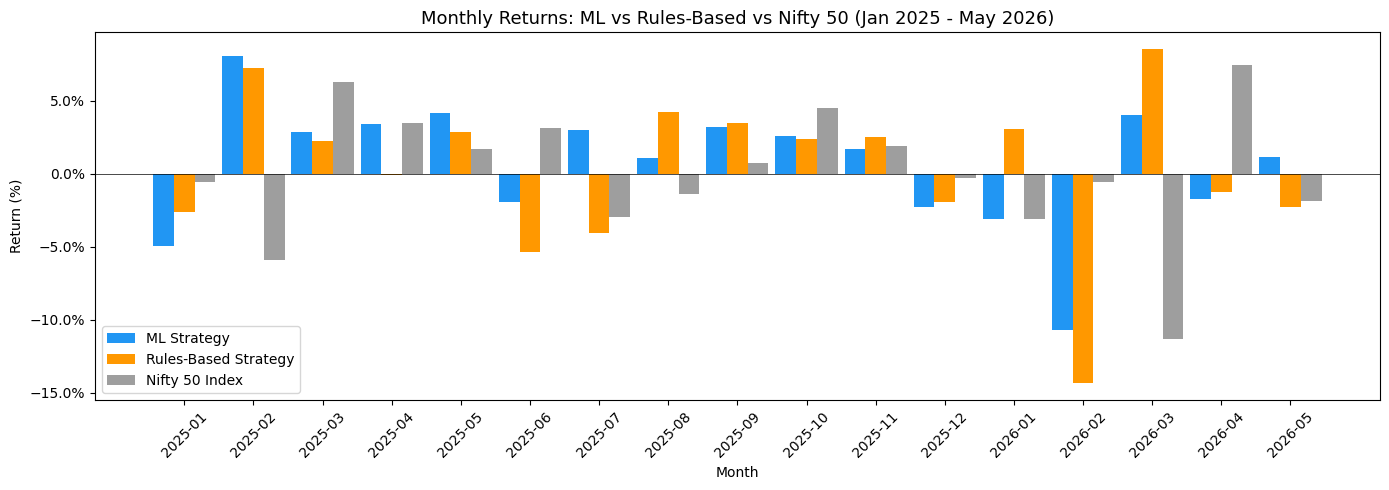

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

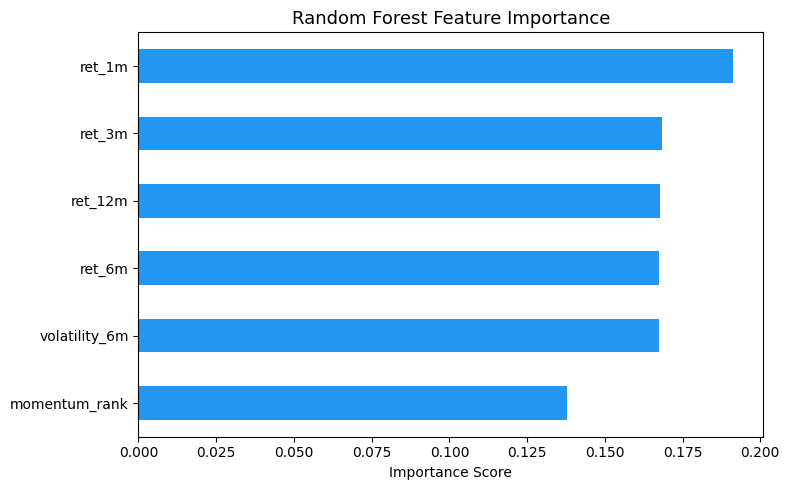

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

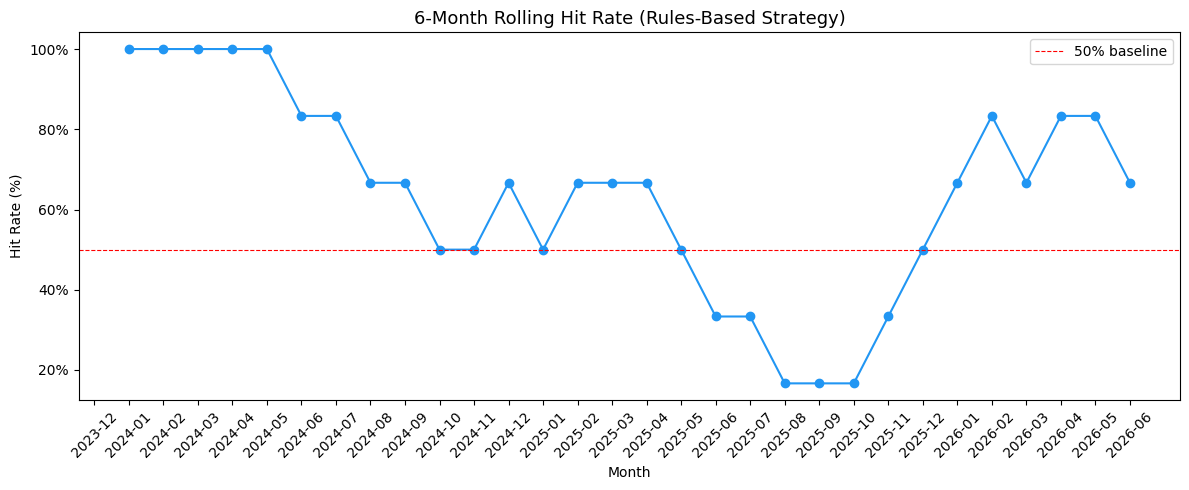

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

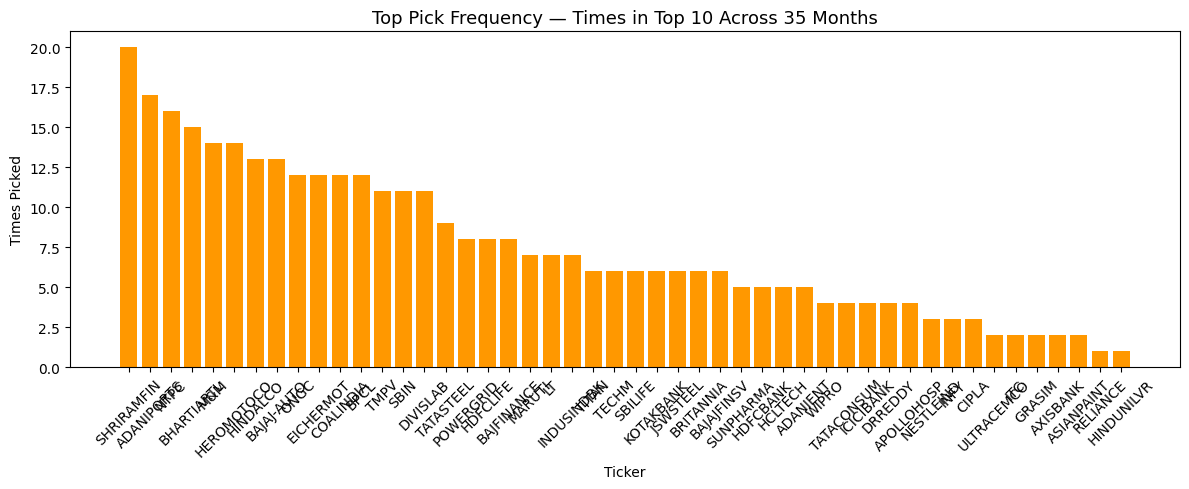

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files

# Chart 1 - Cumulative Return
comp['cum_ml']    = (1 + comp['ml_return']).cumprod() - 1
comp['cum_rules'] = (1 + comp['rules_return']).cumprod() - 1
comp['cum_index'] = (1 + comp['index_ret']).cumprod() - 1

plt.figure(figsize=(12, 5))
plt.plot(comp['month'], comp['cum_ml']    * 100, marker='o', label='ML Strategy',          color='#2196F3')
plt.plot(comp['month'], comp['cum_rules'] * 100, marker='o', label='Rules-Based Strategy',  color='#FF9800')
plt.plot(comp['month'], comp['cum_index'] * 100, marker='o', label='Nifty 50 Index',        color='#9E9E9E', linestyle='--')
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Cumulative Return: ML vs Rules-Based vs Nifty 50 (Jan 2025 - May 2026)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Cumulative Return (%)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.tight_layout()
plt.savefig('cumulative_return.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('cumulative_return.png')

# Chart 2 - Monthly Returns Bar
x = range(len(comp))
width = 0.3
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar([i - width for i in x], comp['ml_return']    * 100, width=width, label='ML Strategy',          color='#2196F3')
ax.bar([i          for i in x], comp['rules_return'] * 100, width=width, label='Rules-Based Strategy',  color='#FF9800')
ax.bar([i + width for i in x], comp['index_ret']    * 100, width=width, label='Nifty 50 Index',        color='#9E9E9E')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Monthly Returns: ML vs Rules-Based vs Nifty 50 (Jan 2025 - May 2026)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Return (%)')
ax.set_xticks(list(x))
ax.set_xticklabels(comp['month'], rotation=45)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig('monthly_returns.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('monthly_returns.png')

# Chart 3 - Feature Importance
feat_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
feat_importance.plot(kind='barh', color='#2196F3')
plt.title('Random Forest Feature Importance', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('feature_importance.png')

# Chart 4 - Rolling Hit Rate
full_results['rolling_hit_rate'] = full_results['beat'].rolling(6).mean() * 100
plt.figure(figsize=(12, 5))
plt.plot(full_results['holding_month'], full_results['rolling_hit_rate'], marker='o', color='#2196F3')
plt.axhline(50, color='red', linestyle='--', linewidth=0.8, label='50% baseline')
plt.title('6-Month Rolling Hit Rate (Rules-Based Strategy)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Hit Rate (%)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.legend()
plt.tight_layout()
plt.savefig('rolling_hit_rate.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('rolling_hit_rate.png')

# Chart 5 - Top Picks Frequency
plt.figure(figsize=(12, 5))
plt.bar(top_picks_all['ticker'], top_picks_all['times_picked'], color='#FF9800')
plt.title('Top Pick Frequency — Times in Top 10 Across 35 Months', fontsize=13)
plt.xlabel('Ticker')
plt.ylabel('Times Picked')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_picks_frequency.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('top_picks_frequency.png')